<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_14_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 1
A logistic regression model predicts the probability of a student passing an exam:  

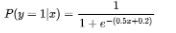

Here x is hours studied.  
a) What is the probability of passing if a student studies 2 hours?  
b) What is the decision boundary value of x (where probability = 0.5)?


a. Here, z = (0.5 * 2) + 0.2 = 1.2. So, P(y=1|x) = 1/(1+2.71828^(-1.2)) ≈ 0.769 (≈76.9%)

b. decision boundary, p = -(0.5x + 0.2 = 0) → x = -0.4

# Problem 2
Given a single data point: actual y = 1, predicted probability ŷ = 0.3.  
Calculate the Log Loss for this single example.


Formula: Log Loss = -[y * log(p) + (1 - y) * log(1 - p)]

so, Log Loss = -[(1 * ln(0.3)) + (1 - 1) * ln(1 - 0.3)]
             = -[(1 * -0.523) + (0 * -0.155)]
             = 1.204

# Problem 3
You train a logistic regression model with weight w = 2.0  and bias b = -1.0.  
For a feature vector x = [1.5, 0.5],  
a) Compute z = w·x + b  
b) Compute the predicted probability ŷ = σ(z).  
c) If actual y = 1, should the model update w to increase or decrease? Brief some reasoning


a. z = wx1 + wx2 + b = (2.0 * 1.5) + (2.0 * 0.5) + (-1.0) = 3

b. ŷ = 1 / (1 + 2.71828^-3) = 0.9525

c. if y = 1 then, (1-0.9525) = 0.0475. the model should increase the weight to move closer value to ŷ

# Problem 4
A logistic regression model gives the following probabilities for 5 test samples:  
[0.1, 0.4, 0.6, 0.9, 0.45]

Actual labels: [0, 0, 1, 1, 0]  
Using threshold = 0.5:  
a) Find predicted classes.  
b) Calculate accuracy.  
c) How many false positives and false negatives?


In [14]:
import numpy as np

X = np.array([0.1, 0.4, 0.6, 0.9, 0.45])
y = np.array([0, 0, 1, 1, 0])

w_init = 0.5
b_init = 1.0

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def make_prediction(X, w, b, threshold = 0.5):
  m = X.shape[0]
  prob_list = np.zeros((m))

  for i in range(m):
    z = w * X[i] + b
    prob_list[i] = sigmoid(z)

  prediction = (prob_list > threshold)

  return prediction

# a) Predicted classes
predictions = make_prediction(X, w_init, b_init)
print('Predictions:', predictions.astype(int))

# Calculate accuracy.
accuracy = np.mean(predictions == y)
print(f'Accuracy: {accuracy:.1%}')

# c) False positives and false negatives
fp = np.sum((predictions == 1) & (y == 0))
fn = np.sum((predictions == 0) & (y == 1))
print(f'False positives: {fp}')
print(f'False negatives: {fn}')
# How many false positives and false negatives?
# Ans: 3 false positives and no false negatives

Predictions: [1 1 1 1 1]
Accuracy: 40.0%
False positives: 3
False negatives: 0


# Problem 5
A logistic regression model is trained on a dataset with 2 features.  
The learned parameters are: w = [1.2, -0.8], b = 0.5.  
a) Write the equation of the decision boundary.  
b) A new point has x1 = 2.0, x2 = 1.5. Which class is predicted?  
c) How far (in terms of z value) is this point from the decision boundary?


a) Write the equation of the decision boundary.
- Equation: z = w1X1 + w2X2 + b = 0

b) A new point has x1 = 2.0, x2 = 1.5. Which class is predicted?
- z = (1.2 * 2.0) + (-0.8 * 1.5) + 0.5 = 1.7
- σ(1.7) = 1 / (1 +  2.71828⁻¹·⁷) ≈ 0.846
since 0.846 > 0.5, we can say that the predicted class is 1 because,
   - If probability ≥ 0.5 → predict class 1
   - If probability < 0.5 → predict class 0

c) How far (in terms of z value) is this point from the decision boundary?
- The z-value itself measures distance from the boundary in "logit space" — at the boundary z = 0, so the distance is simply:
z = 1.7  →  1.7 units above the boundary

# Problem 6
You are given a highly imbalanced dataset: 95% negative class (0) and 5% positive class (1).  
You train a logistic regression model and get 95% accuracy, but it predicts all samples as class 0.  
a) Why is accuracy misleading here?  
b) Which evaluation metric(s) would you use instead?  
c) How can you adjust the model to detect more positive samples?


a) Why is accuracy misleading here?
- Because the dataset includes 95% negative class which means the probability of predicting correct data is (1 - 0.95) = 0.05. since 95% of samples are class 0, predicting class 0 for everything gives 95% correct predictions automatically. The model learned nothing — it just exploits the majority class. Accuracy fails because it counts all correct predictions equally, so the huge volume of true negatives masks the complete failure on positives.

b) Which evaluation metric(s) would you use instead?
- I would use
  - Recall — most critical here, since the model catches zero positives
  - ROC-AUC — measures discrimination ability across all thresholds
  - Confusion Matrix — directly reveals the failure

c) How can you adjust the model to detect more positive samples?
- I would do Three adjustments: lower the decision threshold below 0.5 to make the model more willing to predict positive; set class_weight='balanced' to penalize minority class errors more during training; resample the data by oversampling positives (e.g. SMOTE) or undersampling negatives.

# Problem 7
Write pseudocode (or Python-like logic) for the following functions in logistic regression from scratch (no libraries except numpy for basic ops):  
a) sigmoid(z)

b) predict_probability(X, w, b)

c) compute_cost(X, y, w, b)

d) compute_gradients(X, y, w, b)

e) gradient_descent(X, y, w_init, b_init, alpha, iterations)

Focus on the loops and formulas, not exact Python syntax.


In [18]:
# a) sigmoid(z)
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

# b) predict_probability(X, w, b)
def make_prediction(X, w, b, threshold = 0.5):
  m = X.shape[0]
  prob_list = np.zeros((m,))

  for i in range(m):
    z = np.dot(w, X[i]) + b
    prob_list[i] = sigmoid(z)

  prediction = (prob_list > threshold)

  return prediction

print(make_prediction(X, w_init, b_init))

# c) compute_cost(X, y, w, b)
def compute_cost(X, y, w, b):
  m = X.shape[0]
  cost = 0.0

  for i in range(m):
    z = np.dot(w, X[i]) + b
    probability = sigmoid(z)

    cost = cost + ((y[i] * np.log(probability)) + ((1 - y[i]) * np.log(1 - probability)))

  cost = cost / (-m)
  return cost

# d) compute_gradients(X, y, w, b)
def compute_gradients(X, y, w, b):
  m, n = X.shape
  dj_dw = np.zeros((n))
  dj_db = 0.0

  for i in range(m):
    z = np.dot(w, X[i]) + b
    probability = sigmoid(z)
    error = probability - y[i]

    dj_db = dj_db + error

    for j in range(n):
      dj_dw[j] = dj_dw[j] + (error * X[i, j])

  return dj_dw / m, dj_db / m

# e) gradient_descent(X, y, w_init, b_init, alpha, iterations)
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  w = w_input
  b = b_input
  cost_history = []

  for i in range(max_iter):
    # Step 1: Compute gradients
    dj_dw, dj_db = compute_gradients(X, y, w, b)

    # Step 2: Update parameters (w = w - learning_rate * gradient)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # Step 3: Record the cost to monitor convergence
    if i % 100 == 0:
      cost = compute_cost(X, y, w, b)
      cost_history.append(cost)
      print(f"Iter {i}: Cost {cost:.4f}")

  return w, b, cost_history

[ True  True  True  True  True]
